# CS506 Project Check-In (March): Boston Rent Prediction


- Preliminary visualizations  
- Data processing summary (what I have done so far)  
- Modeling methods used so far  
- Preliminary results + interpretation  

Dataset used: `ma_boston_housing.csv` (Boston area listings filtered from the housing dataset) `housing.csv`(US housing dataset that I downloaded from kaggle)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "../data/ma_boston_housing.csv"  # adjust if needed
df = pd.read_csv(DATA_PATH)

df.head()


,id,url,region,region_url,price,type,sqfeet,beds,baths,cats_allowed,...,wheelchair_access,electric_vehicle_charge,comes_furnished,laundry_options,parking_options,image_url,description,lat,long,state
0,7048591916,https://boston.craigslist.org/gbs/apa/d/waverl...,boston,https://boston.craigslist.org,2450,apartment,950,2,2.0,1,...,0,0,0,laundry on site,off-street parking,https://images.craigslist.org/00Y0Y_4Nw47FbvqM...,Contact info: Owned and Managed by The Hamilt...,42.4235,-71.2166,ma
1,7048584795,https://boston.craigslist.org/bmw/apa/d/concor...,boston,https://boston.craigslist.org,1747,apartment,975,2,2.0,1,...,0,0,0,w/d in unit,off-street parking,https://images.craigslist.org/00O0O_hgVU1Dt4yZ...,"The Prescott at Concord 1 Nathan Pratt Drive, ...",42.4567,-71.3747,ma
2,7048579724,https://boston.craigslist.org/bmw/apa/d/concor...,boston,https://boston.craigslist.org,1667,apartment,719,1,1.0,1,...,0,0,0,w/d in unit,off-street parking,https://images.craigslist.org/00O0O_hgVU1Dt4yZ...,DISTINCT DESIGN IN A RURAL OASIS When it comes...,42.4567,-71.3747,ma
3,7038629072,https://boston.craigslist.org/sob/apa/d/stough...,boston,https://boston.craigslist.org,2400,condo,1400,3,1.5,1,...,0,0,0,laundry on site,attached garage,https://images.craigslist.org/00P0P_3xUxq7idjZ...,This condo is 3 bedroom unit with 1.5 bathroom...,42.1399,-71.1329,ma
4,7041351743,https://boston.craigslist.org/gbs/apa/d/revere...,boston,https://boston.craigslist.org,2400,apartment,1100,2,2.0,1,...,1,0,0,laundry in bldg,attached garage,https://images.craigslist.org/00l0l_8I60XIFhZF...,"2 bedrooms available. Heat, AC, and Hot Water ...",42.4138,-71.0052,ma


## Data Processing Done So Far (Summary)

**Filtering**
- Filtered the full USA housing listings dataset to `state == "ma"`.
- Further filtered to `region == "boston"` (Boston area listings).

**Cleaning**
- Converted key columns to numeric: `price`, `beds`, `baths`, `sqfeet`.
- Removed listings with invalid or missing `price`.
- Removed extreme price outliers (kept prices between **$500** and **$15,000**).
- Deduplicated listings using the listing `id`.

These steps reduce noise and create a cleaner dataset for modeling.


In [11]:
print("Shape:", df.shape)
df[["price", "beds", "baths", "sqfeet"]].describe()


Shape: (1576, 22)


,price,beds,baths,sqfeet
count,1576.000000,1576.000000,1576.000000,1576.000000
mean,2394.010152,1.905457,1.295051,1698.451777
std,871.744157,0.991684,0.520562,25172.232522
min,550.000000,0.000000,0.000000,0.000000
25%,1800.000000,1.000000,1.000000,750.000000
50%,2239.000000,2.000000,1.000000,989.000000
75%,2800.000000,2.000000,2.000000,1232.500000
max,10000.000000,6.000000,4.500000,999999.000000


## Preliminary Visualizations



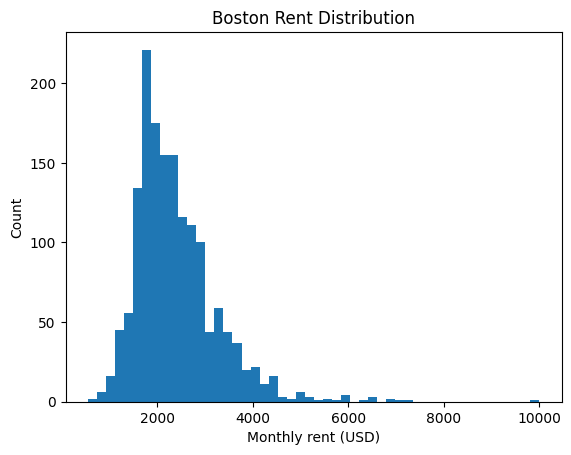

/var/folders/r8/ml4vhxjs71s5ynx4vpchtp_m0000gn/T/ipykernel_79897/2863246733.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


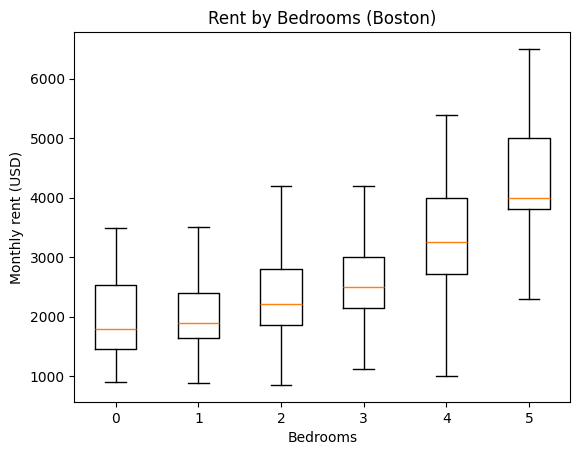

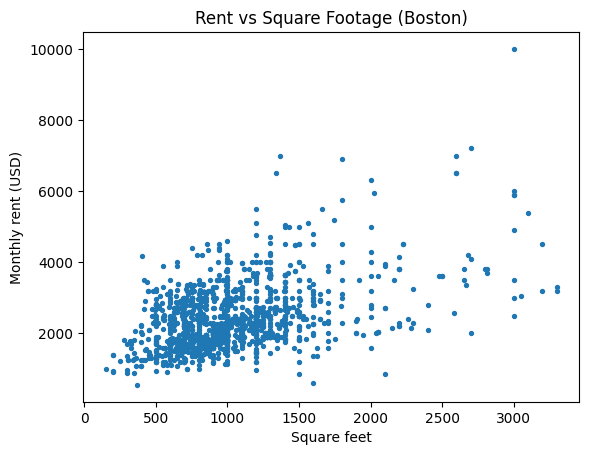

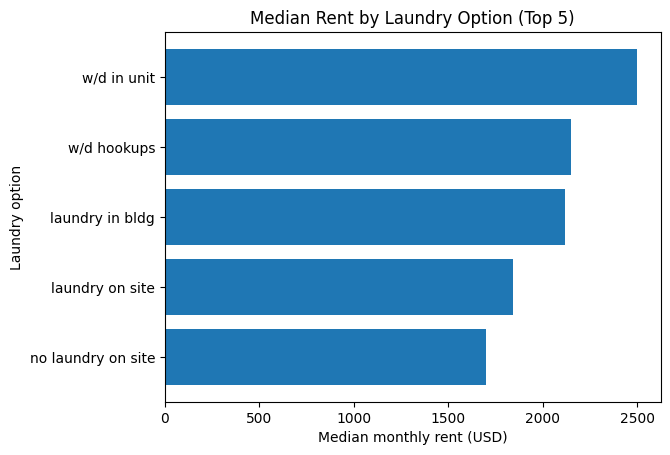

In [16]:
import matplotlib.pyplot as plt

# 1) Rent distribution
plt.figure()
plt.hist(df["price"], bins=50)
plt.title("Boston Rent Distribution")
plt.xlabel("Monthly rent (USD)")
plt.ylabel("Count")
plt.show()


# 2) Rent by bedrooms (boxplot)
if "beds" in df.columns:
    beds_vals = sorted([b for b in df["beds"].dropna().unique() if b <= 5])
    groups = [df.loc[df["beds"] == b, "price"].dropna() for b in beds_vals]
    labels = [str(b) for b in beds_vals]
    plt.figure()
    plt.boxplot(groups, labels=labels, showfliers=False)
    plt.title("Rent by Bedrooms (Boston)")
    plt.xlabel("Bedrooms")
    plt.ylabel("Monthly rent (USD)")
    plt.show()

# 3) Rent vs square footage (scatter)
if "sqfeet" in df.columns:
    sub = df.dropna(subset=["sqfeet"]).copy()
    # remove extreme sqft outliers for readability (optional)
    sub = sub[(sub["sqfeet"] > 100) & (sub["sqfeet"] < 5000)]
    plt.figure()
    plt.scatter(sub["sqfeet"], sub["price"], s=8)
    plt.title("Rent vs Square Footage (Boston)")
    plt.xlabel("Square feet")
    plt.ylabel("Monthly rent (USD)")
    plt.show()

# 4) Median rent by laundry option (example categorical insight)
if "laundry_options" in df.columns:
    med = df.groupby("laundry_options")["price"].median().sort_values(ascending=False)
    med = med[med.index.notna()]
    # show top 10 categories
    med = med.head(10)
    plt.figure()
    plt.barh(list(med.index)[::-1], list(med.values)[::-1])
    plt.title("Median Rent by Laundry Option (Top 5)")
    plt.xlabel("Median monthly rent (USD)")
    plt.ylabel("Laundry option")
    plt.show()


## Modeling Methods Used So Far

**Task:** Predict monthly rent price (`price`) from listing features.

**Baseline**
always predict the median rent from the training set.




In [18]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import KNeighborsRegressor
from sklearn.cluster import KMeans

# -------------------------
# Load + cleaning
# -------------------------
df = pd.read_csv("../data/ma_boston_housing.csv").copy()
df["description"] = df["description"].fillna("").astype(str)

for col in ["price", "beds", "baths", "sqfeet", "lat", "long"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df[df["price"].notna()].copy()
df = df[(df["price"] >= 500) & (df["price"] <= 15000)]
df = df.drop_duplicates(subset=["id"])

# -------------------------
# Quality signals from text
# -------------------------
luxury_keywords = [
    "luxury","renovated","stainless","granite","hardwood","doorman","concierge",
    "gym","fitness","roof deck","rooftop","central air","in-unit","in unit",
    "washer","dryer","laundry in unit","floor to ceiling","penthouse","garage",
    "valet","waterfront","pool","new construction"
]
transit_keywords = [
    "near t","mbta","red line","green line","orange line","blue line",
    "subway","station","commuter rail"
]

def keyword_score(text, keywords):
    t = str(text).lower()
    return sum(1 for kw in keywords if kw in t)

desc = df["description"].str.lower()
df["luxury_score"] = desc.apply(lambda t: keyword_score(t, luxury_keywords))
df["transit_score"] = desc.apply(lambda t: keyword_score(t, transit_keywords))
df["no_fee"] = desc.str.contains("no fee", na=False).astype(int)

# -------------------------
# Location / neighborhood proxy features
# -------------------------
DOWNTOWN_LAT, DOWNTOWN_LON = 42.3601, -71.0589

if "lat" in df.columns and "long" in df.columns:
    df["dist_downtown"] = np.sqrt((df["lat"] - DOWNTOWN_LAT)**2 + (df["long"] - DOWNTOWN_LON)**2)

    geo = df[["lat", "long"]].dropna().copy()
    if len(geo) > 50:
        geo_scaled = StandardScaler().fit_transform(geo)
        k_geo = 12
        geo_labels = KMeans(n_clusters=k_geo, random_state=42, n_init=10).fit_predict(geo_scaled)
        df.loc[geo.index, "geo_cluster"] = geo_labels
    df["geo_cluster"] = df.get("geo_cluster", -1).fillna(-1).astype(int)

# -------------------------
# Features
# -------------------------
text_feature = "description"

num_features = [c for c in [
    "beds","baths","sqfeet","lat","long",
    "luxury_score","transit_score","no_fee",
    "dist_downtown"
] if c in df.columns]

cat_features = [c for c in ["type","laundry_options","parking_options","geo_cluster"] if c in df.columns]

X = df[num_features + cat_features + [text_feature]].copy()
y = df["price"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

baseline_pred = np.full(shape=len(y_test), fill_value=y_train.median())
baseline_mae = mean_absolute_error(y_test, baseline_pred)
print("Baseline (median) MAE:", round(baseline_mae, 2))

# -------------------------
# Tuned LSA + KNN (your best settings)
# -------------------------
text_pipe = Pipeline(steps=[
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        max_features=30000,
        min_df=3,
        ngram_range=(1, 2)
    )),
    ("svd", TruncatedSVD(n_components=75, random_state=42)),
    ("scale", StandardScaler())
])

num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("text", text_pipe, text_feature),
        ("num", num_pipe, num_features),
        ("cat", cat_pipe, cat_features),
    ],
    remainder="drop"
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("knn", KNeighborsRegressor(n_neighbors=5, weights="distance"))
])

model.fit(X_train, y_train)
pred = model.predict(X_test)
mae = mean_absolute_error(y_test, pred)

print("Location-improved tuned LSA + KNN MAE:", round(mae, 2))
print("Improvement (baseline - model):", round(baseline_mae - mae, 2))

Baseline (median) MAE: 602.59
Location-improved tuned LSA + KNN MAE: 301.09
Improvement (baseline - model): 301.5


# Tuning K and SVD Components

In [14]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error

k_list = [3, 5, 7, 10, 15]
comp_list = [25, 50, 75]

results = []

for n_comp in comp_list:
    # rebuild text pipeline each time with different SVD dimension
    text_pipe_tmp = Pipeline(steps=[
        ("tfidf", TfidfVectorizer(
            stop_words="english",
            max_features=30000,
            min_df=3,
            ngram_range=(1, 2)
        )),
        ("svd", TruncatedSVD(n_components=n_comp, random_state=42)),
        ("scale", StandardScaler())
    ])

    num_pipe_tmp = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ])

    cat_pipe_tmp = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocess_tmp = ColumnTransformer(
        transformers=[
            ("text", text_pipe_tmp, text_feature),
            ("num", num_pipe_tmp, num_features),
            ("cat", cat_pipe_tmp, cat_features),
        ],
        remainder="drop"
    )

    for k in k_list:
        model_tmp = Pipeline(steps=[
            ("preprocess", preprocess_tmp),
            ("knn", KNeighborsRegressor(n_neighbors=k, weights="distance"))
        ])

        model_tmp.fit(X_train, y_train)
        pred = model_tmp.predict(X_test)
        mae = mean_absolute_error(y_test, pred)

        results.append((n_comp, k, mae))
        print(f"n_comp={n_comp:<3}  k={k:<2}  MAE={mae:.2f}")

best_n, best_k, best_mae = min(results, key=lambda t: t[2])
print("\nBEST SETTINGS:")
print("n_components =", best_n)
print("k =", best_k)
print("MAE =", round(best_mae, 2))

n_comp=25   k=3   MAE=312.36
n_comp=25   k=5   MAE=303.34
n_comp=25   k=7   MAE=302.71
n_comp=25   k=10  MAE=302.40
n_comp=25   k=15  MAE=309.50
n_comp=50   k=3   MAE=310.99
n_comp=50   k=5   MAE=306.82
n_comp=50   k=7   MAE=302.27
n_comp=50   k=10  MAE=313.70
n_comp=50   k=15  MAE=318.21
n_comp=75   k=3   MAE=311.39
n_comp=75   k=5   MAE=301.18
n_comp=75   k=7   MAE=311.87
n_comp=75   k=10  MAE=314.18
n_comp=75   k=15  MAE=319.41

BEST SETTINGS:
n_components = 75
k = 5
MAE = 301.18


In [20]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error

# assumes df is already cleaned and has:
# description, price, beds, baths, sqfeet, lat, long, luxury_score, transit_score, no_fee, dist_downtown
# and you have X_train/X_test etc from earlier? We'll rebuild splits each loop to keep consistent.

# fixed settings (from your best model)
N_COMP = 75
KNN_K = 5

k_geo_list = [6, 8, 10, 12, 16, 20]
results = []

# Prepare shared text/numeric/cat pipelines (we will rebuild ColumnTransformer because columns differ)
text_pipe = Pipeline(steps=[
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        max_features=30000,
        min_df=3,
        ngram_range=(1, 2)
    )),
    ("svd", TruncatedSVD(n_components=N_COMP, random_state=42)),
    ("scale", StandardScaler())
])

num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

text_feature = "description"
base_num = [c for c in ["beds","baths","sqfeet","luxury_score","transit_score","no_fee","dist_downtown"] if c in df.columns]
base_cat = [c for c in ["type","laundry_options","parking_options"] if c in df.columns]

from sklearn.model_selection import train_test_split

for k_geo in k_geo_list:
    df_tmp = df.copy()

    # geo_cluster creation
    geo = df_tmp[["lat","long"]].dropna().copy()
    geo_scaled = StandardScaler().fit_transform(geo)
    df_tmp.loc[geo.index, "geo_cluster"] = KMeans(n_clusters=k_geo, random_state=42, n_init=10).fit_predict(geo_scaled)
    df_tmp["geo_cluster"] = df_tmp["geo_cluster"].fillna(-1).astype(int)

    # Two configurations
    for use_latlong in [True, False]:
        num_features = base_num.copy()
        if use_latlong:
            num_features += [c for c in ["lat","long"] if c in df_tmp.columns]

        cat_features = base_cat + ["geo_cluster"]

        X = df_tmp[num_features + cat_features + [text_feature]].copy()
        y = df_tmp["price"].copy()

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        preprocess = ColumnTransformer(
            transformers=[
                ("text", text_pipe, text_feature),
                ("num", num_pipe, num_features),
                ("cat", cat_pipe, cat_features),
            ],
            remainder="drop"
        )

        model = Pipeline(steps=[
            ("preprocess", preprocess),
            ("knn", KNeighborsRegressor(n_neighbors=KNN_K, weights="distance"))
        ])

        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        mae = mean_absolute_error(y_test, pred)

        results.append((k_geo, use_latlong, mae))
        mode = "lat/long+cluster" if use_latlong else "cluster-only"
        print(f"k_geo={k_geo:<2}  mode={mode:<14}  MAE={mae:.2f}")

best = min(results, key=lambda t: t[2])
print("\nBEST:", best)

k_geo=6   mode=lat/long+cluster  MAE=298.19
k_geo=6   mode=cluster-only    MAE=298.85
k_geo=8   mode=lat/long+cluster  MAE=300.46
k_geo=8   mode=cluster-only    MAE=302.65
k_geo=10  mode=lat/long+cluster  MAE=298.54
k_geo=10  mode=cluster-only    MAE=301.36
k_geo=12  mode=lat/long+cluster  MAE=301.09
k_geo=12  mode=cluster-only    MAE=303.82
k_geo=16  mode=lat/long+cluster  MAE=300.86
k_geo=16  mode=cluster-only    MAE=303.78
k_geo=20  mode=lat/long+cluster  MAE=302.07
k_geo=20  mode=cluster-only    MAE=305.85

BEST: (6, True, 298.1908370391498)


# Best Model

In [21]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import KNeighborsRegressor
from sklearn.cluster import KMeans

# -------------------------
# Load + cleaning
# -------------------------
df = pd.read_csv("../data/ma_boston_housing.csv").copy()
df["description"] = df["description"].fillna("").astype(str)

for col in ["price", "beds", "baths", "sqfeet", "lat", "long"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df[df["price"].notna()].copy()
df = df[(df["price"] >= 500) & (df["price"] <= 15000)]
df = df.drop_duplicates(subset=["id"])

# -------------------------
# Quality signals from text
# -------------------------
luxury_keywords = [
    "luxury","renovated","stainless","granite","hardwood","doorman","concierge",
    "gym","fitness","roof deck","rooftop","central air","in-unit","in unit",
    "washer","dryer","laundry in unit","floor to ceiling","penthouse","garage",
    "valet","waterfront","pool","new construction"
]
transit_keywords = [
    "near t","mbta","red line","green line","orange line","blue line",
    "subway","station","commuter rail"
]

def keyword_score(text, keywords):
    t = str(text).lower()
    return sum(1 for kw in keywords if kw in t)

desc = df["description"].str.lower()
df["luxury_score"] = desc.apply(lambda t: keyword_score(t, luxury_keywords))
df["transit_score"] = desc.apply(lambda t: keyword_score(t, transit_keywords))
df["no_fee"] = desc.str.contains("no fee", na=False).astype(int)

# -------------------------
# Location / neighborhood proxy features (BEST setting)
# -------------------------
DOWNTOWN_LAT, DOWNTOWN_LON = 42.3601, -71.0589
df["dist_downtown"] = np.sqrt((df["lat"] - DOWNTOWN_LAT)**2 + (df["long"] - DOWNTOWN_LON)**2)

# k_geo = 6
geo = df[["lat", "long"]].dropna().copy()
geo_scaled = StandardScaler().fit_transform(geo)
df.loc[geo.index, "geo_cluster"] = KMeans(n_clusters=6, random_state=42, n_init=10).fit_predict(geo_scaled)
df["geo_cluster"] = df["geo_cluster"].fillna(-1).astype(int)

# -------------------------
# Features
# -------------------------
text_feature = "description"

num_features = [c for c in [
    "beds","baths","sqfeet","lat","long","dist_downtown",
    "luxury_score","transit_score","no_fee"
] if c in df.columns]

cat_features = [c for c in ["type","laundry_options","parking_options","geo_cluster"] if c in df.columns]

X = df[num_features + cat_features + [text_feature]].copy()
y = df["price"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Baseline
baseline_pred = np.full(shape=len(y_test), fill_value=y_train.median())
baseline_mae = mean_absolute_error(y_test, baseline_pred)
print("Baseline (median) MAE:", round(baseline_mae, 2))

# -------------------------
# BEST tuned LSA + KNN settings
# -------------------------
text_pipe = Pipeline(steps=[
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        max_features=30000,
        min_df=3,
        ngram_range=(1, 2)
    )),
    ("svd", TruncatedSVD(n_components=75, random_state=42)),
    ("scale", StandardScaler())
])

num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("text", text_pipe, text_feature),
        ("num", num_pipe, num_features),
        ("cat", cat_pipe, cat_features),
    ],
    remainder="drop"
)

best_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("knn", KNeighborsRegressor(n_neighbors=5, weights="distance"))
])

best_model.fit(X_train, y_train)
pred = best_model.predict(X_test)

best_mae = mean_absolute_error(y_test, pred)
print("BEST model MAE (k_geo=6, KNN k=5, SVD=75):", round(best_mae, 2))
print("Improvement (baseline - best):", round(baseline_mae - best_mae, 2))

Baseline (median) MAE: 602.59
BEST model MAE (k_geo=6, KNN k=5, SVD=75): 298.19
Improvement (baseline - best): 304.4
